# DS-Wave non-adaptive testing

Standalone DS-Wave target solving and toroidal point synthesis.

In [24]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # For Windows

import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.10.0+cu128
True


In [25]:
from pathlib import Path
import importlib.util
import sys

import matplotlib.pyplot as plt
import numpy as np

import plotly.graph_objects as go
import nbformat
print(nbformat.__version__)
print(nbformat.__file__)


module_path = Path("ds-wave.py").resolve()
if not module_path.exists():
	module_path = Path("python") / "ds-wave.py"
module_path = module_path.resolve()
spec = importlib.util.spec_from_file_location("ds_wave", module_path)
ds_wave = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ds_wave)

python_dir = Path("python").resolve()
if python_dir.exists() and str(python_dir) not in sys.path:
	sys.path.insert(0, str(python_dir))
import ds_wave_3D as ds_wave_3d

plt.rcParams["figure.dpi"] = 120


5.10.4
c:\Users\ville\anaconda3\envs\bluenoise_pointprocesses\Lib\site-packages\nbformat\__init__.py


In [26]:
# Easy-to-edit parameters
#nu0 = 0.85
nu0 = 0.70
e0 = 0.0
nu_max = 10.0
n_nu = 1001
n_r = 128
n_points = 2048
iterations = 1000
seed = 1234
m0_values = [1.0, 2.0, "min"]
device = "auto"
spectrum_learning_rate = 0.03
mode_limit = 12000
mode_chunk_size = 512
low_frequency_weight = 50.0

# Options: ds_wave.SynthesisMode.SPECTRUM_MATCHING or ds_wave.SynthesisMode.PCF_MATCHING
synthesis_mode = ds_wave.SynthesisMode.PCF_MATCHING
pcf_step_scale = 1.0
pcf_num_bins = None  # None uses n_points, matching targetrdf
pcf_smoothing = 8.0  # RDF Gaussian smoothing in bins, matching targetrdf default
pcf_chunk_size = 256
initial_points = None

m0=1.0: infeasible - The problem is infeasible. (HiGHS Status 8: model_status is Infeasible; primal_status is None)
m0=2.0: optimal - Optimization terminated successfully. (HiGHS Status 7: Optimal)
m0=min: optimal - Optimization terminated successfully. (HiGHS Status 7: Optimal)


C:\Users\ville\AppData\Local\Temp\ipykernel_91776\2157386874.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


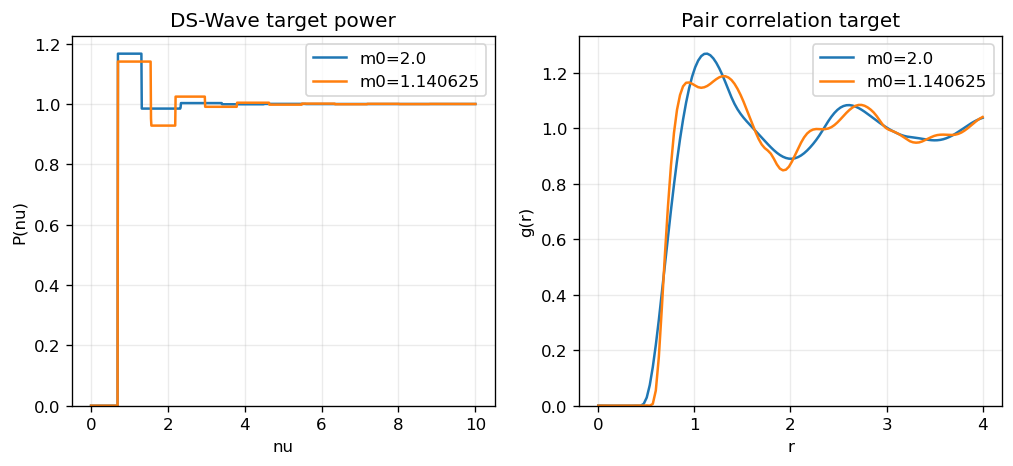

In [27]:
targets = {}
for m0 in m0_values:
	target = ds_wave.solve_ds_wave_target(
		nu0=nu0,
		e0=e0,
		m0=m0,
		nu_max=nu_max,
		n_nu=n_nu,
		n_r=n_r,
		require_success=False,
	)
	targets[str(m0)] = target
	print(f"m0={m0}: {target['status']} - {target['message']}")

fig = ds_wave.plot_ds_wave_targets(list(targets.values()))
fig.show()

In [28]:
print(targets.keys())
min_target = targets["min"]
if not min_target["success"]:
	raise RuntimeError(min_target["message"])

synthesis = ds_wave.synthesize_toroidal_points(
	min_target,
	n_points=n_points,
	iterations=iterations,
	seed=seed,
	device=device,
	spectrum_learning_rate=spectrum_learning_rate,
	mode_limit=mode_limit,
	mode_chunk_size=mode_chunk_size,
	low_frequency_weight=low_frequency_weight,
	synthesis_mode=synthesis_mode,
	pcf_step_scale=pcf_step_scale,
	pcf_num_bins=pcf_num_bins,
	pcf_smoothing=pcf_smoothing,
	pcf_chunk_size=pcf_chunk_size,
	initial_points=initial_points,
	log_every=max(100, 1),
)
points = synthesis["points"]
print(f"mode={synthesis['synthesis_mode']}, device={synthesis['device']}, final energy={synthesis['energy_history'][-1]:.6g}")
print(points.shape, points.min(), points.max())
print(synthesis["iterations_run"])
print(len(synthesis["energy_history"]))

print("Energy history:")
for e in synthesis["energy_history"][-10:]:
	print(e)

dict_keys(['1.0', '2.0', 'min'])
mode=pcf_matching, device=cuda, final energy=0.0081316
(2048, 2) 0.00011078374 0.99979734
1000
11
Energy history:
0.008131604108397698
0.008131604108397698
0.008131604108397698
0.008131604108397698
0.008131604108397698
0.008131604108397698
0.008131604108397698
0.008131604108397698
0.008131604108397698
0.008131604108397698


C:\Users\ville\AppData\Local\Temp\ipykernel_91776\3835064014.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


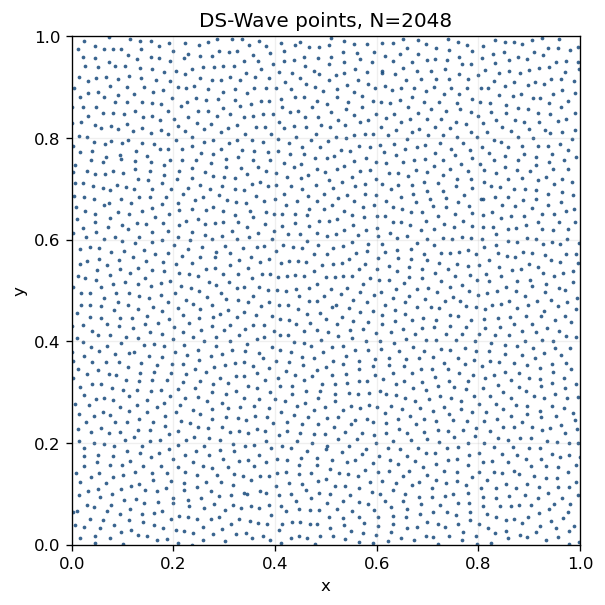

In [29]:
fig = ds_wave.plot_points(points, title=f"DS-Wave points, N={n_points}")
fig.show()

C:\Users\ville\AppData\Local\Temp\ipykernel_91776\3426012565.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


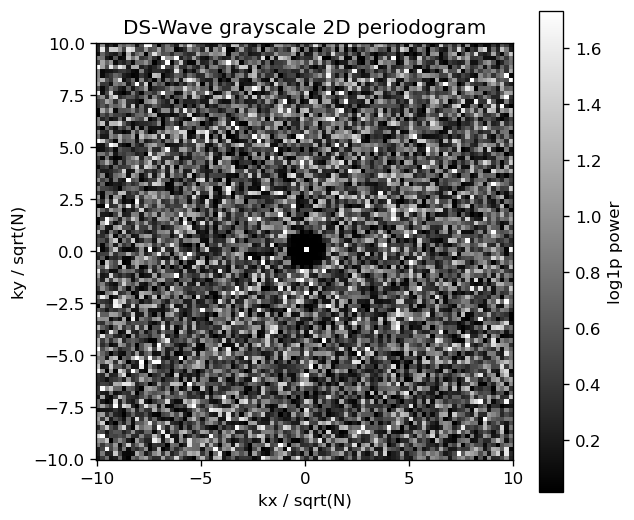

In [30]:
power_2d, extent = ds_wave.compute_periodogram_2d(points, grid_size=96, max_freq=nu_max)
fig = ds_wave.plot_periodogram(power_2d, extent, title="DS-Wave grayscale 2D periodogram")
fig.show()

C:\Users\ville\AppData\Local\Temp\ipykernel_91776\2930057178.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


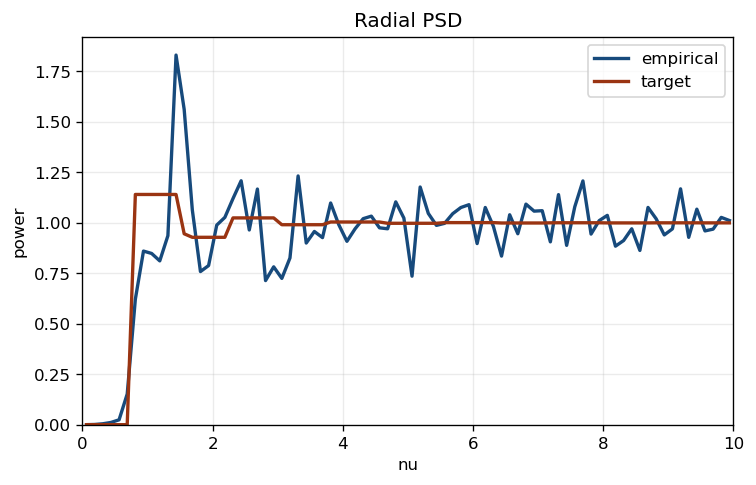

In [31]:
fig = ds_wave.plot_radial_psd_overlay(points, min_target, max_freq=nu_max)
fig.show()

C:\Users\ville\AppData\Local\Temp\ipykernel_91776\3071173755.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


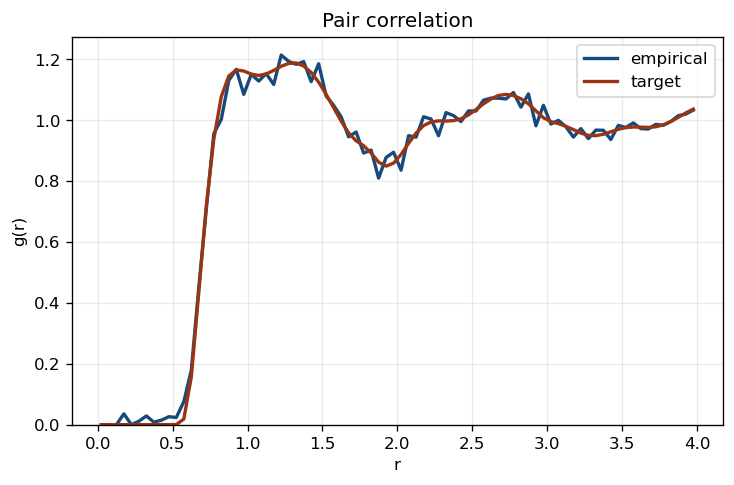

In [32]:
fig = ds_wave.plot_pcf_overlay(points, min_target)
fig.show()

3D m0=1.03125: optimal - Optimization terminated successfully. (HiGHS Status 7: Optimal)


C:\Users\ville\AppData\Local\Temp\ipykernel_91776\3526833486.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


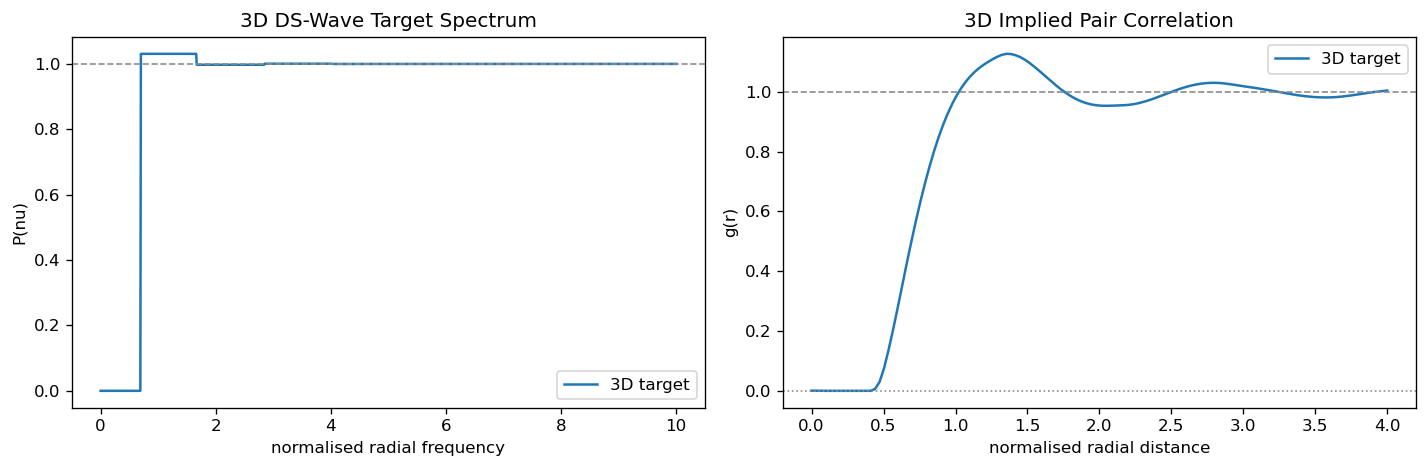

In [33]:
# 3D DS-Wave target exploration
# This solves/plots the optimized 3D target spectrum and implied g(r).

target_3d = ds_wave_3d.solve_ds_wave_target_3d(
	nu0=nu0,
	e0=e0,
	m0="min",
	nu_max=nu_max,
	n_nu=n_nu,
	n_r=n_r,
	require_success=False,
)
print(f"3D m0={target_3d['m0']}: {target_3d['status']} - {target_3d['message']}")
if not target_3d["success"]:
	raise RuntimeError(target_3d["message"])

fig = ds_wave_3d.plot_3d_target(target_3d)
fig.show()


In [ ]:
# 3D DS-Wave point synthesis
n_points_3d = 4096
iterations_3d = 5 * iterations
pcf_num_bins_3d = pcf_num_bins
pcf_smoothing_3d = pcf_smoothing
pcf_step_scale_3d = pcf_step_scale
pcf_chunk_size_3d = pcf_chunk_size

synthesis_3d = ds_wave_3d.synthesize_toroidal_points_3d(
	target_3d,
	n_points=n_points_3d,
	iterations=iterations_3d,
	seed=seed,
	device=device,
	step_scale=pcf_step_scale_3d,
	nbins=pcf_num_bins_3d,
	smoothing=pcf_smoothing_3d,
	chunk_size=pcf_chunk_size_3d,
	log_every=max(iterations_3d // 10, 1),
)
points_3d = synthesis_3d["points"]
print(f"3D points: {points_3d.shape}, device={synthesis_3d['device']}")
print("Energy history:")
for value in synthesis_3d["energy_history"]:
	print(value)

fig = plt.figure(figsize=(6, 6), dpi=120)
ax = fig.add_subplot(111, projection="3d")
ax.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2], s=2.0, c="black", linewidths=0)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_zlim(0, 1)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title(f"3D DS-Wave points, N={n_points_3d}")
try:
	ax.set_box_aspect((1, 1, 1))
except AttributeError:
	pass
fig.tight_layout()
fig.show()

fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
ax.plot(synthesis_3d["r_values"], synthesis_3d["target_rdf"], label="target")
ax.plot(synthesis_3d["r_values"], synthesis_3d["final_rdf"], label="empirical")
ax.axhline(1.0, color="0.55", linestyle="--", linewidth=1)
ax.set_xlabel("normalised radial distance")
ax.set_ylabel("g(r)")
ax.set_title("3D DS-Wave TargetRDF match")
ax.legend()
fig.tight_layout()
fig.show()


In [ ]:
fig = go.Figure(
	data=[
		go.Scatter3d(
			x=points_3d[:, 0],
			y=points_3d[:, 1],
			z=points_3d[:, 2],
			mode="markers",
			marker=dict(
				size=2,
				color="black",
				opacity=0.75,
			),
		)
	]
)

fig.update_layout(
	title=f"3D DS-Wave points, N={n_points_3d}",
	scene=dict(
		xaxis=dict(range=[0, 1], title="x"),
		yaxis=dict(range=[0, 1], title="y"),
		zaxis=dict(range=[0, 1], title="z"),
		aspectmode="cube",
	),
	width=750,
	height=750,
)

fig.show()

C:\Users\ville\AppData\Local\Temp\ipykernel_91776\2601980121.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


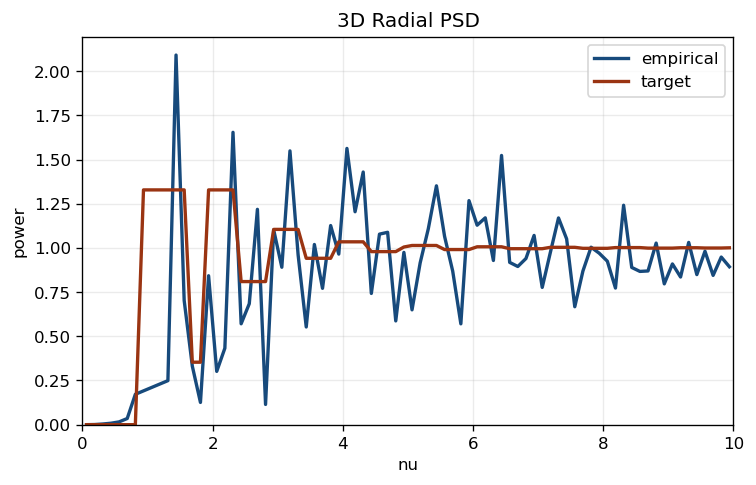

In [ ]:
# 3D radial PSD diagnostic
psd_num_bins_3d = 80
psd_mode_limit_3d = 12000

fig = ds_wave_3d.plot_radial_psd_overlay_3d(
	points_3d,
	target_3d,
	num_bins=psd_num_bins_3d,
	max_freq=nu_max,
	mode_limit=psd_mode_limit_3d,
)
fig.show()


C:\Users\ville\AppData\Local\Temp\ipykernel_91776\2737008937.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


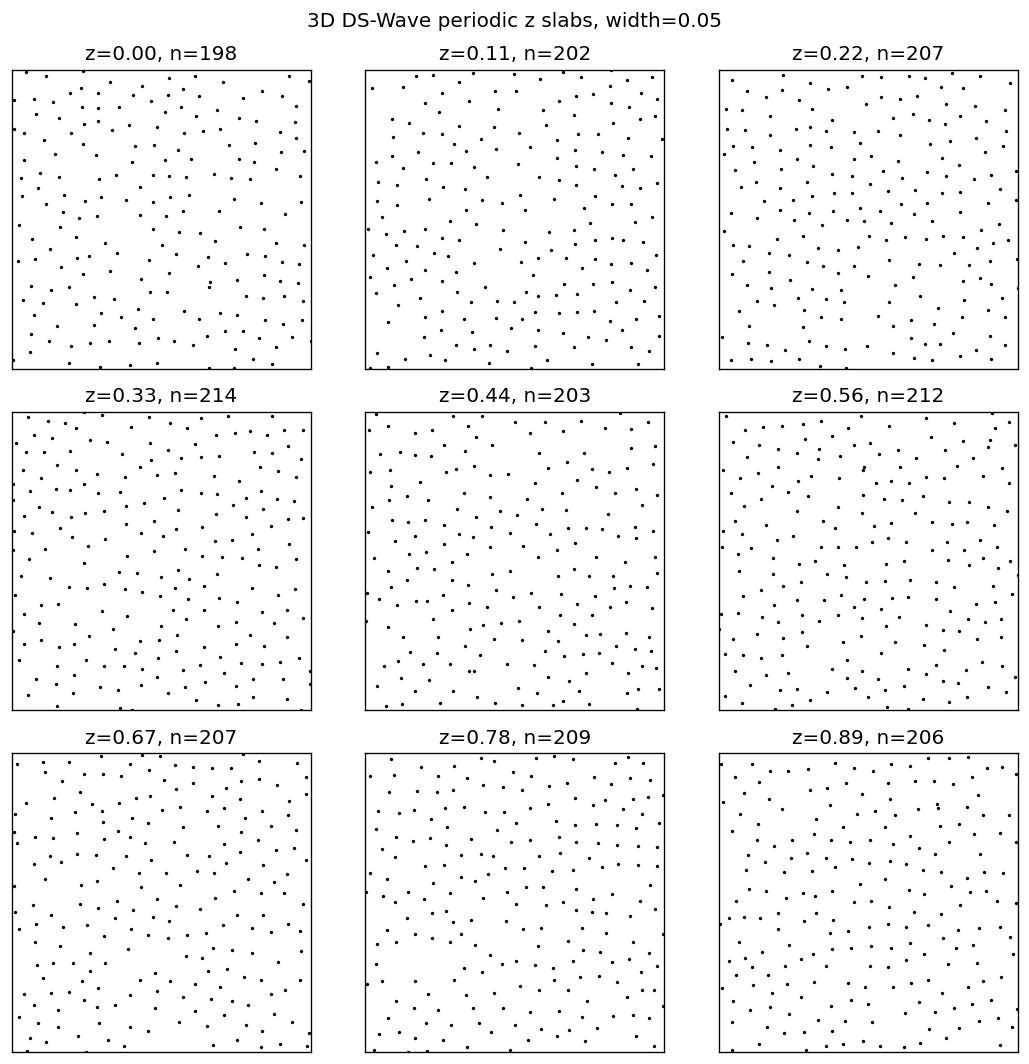

In [ ]:
# 3D slice visualization: several periodic z slabs
slice_width = 0.05
slice_z_values = np.linspace(0.0, 1.0, 9, endpoint=False)

fig, axes = plt.subplots(3, 3, figsize=(9, 9), dpi=120)
for ax, z0 in zip(axes.ravel(), slice_z_values):
	dz = np.abs(points_3d[:, 2] - z0)
	dz = np.minimum(dz, 1.0 - dz)
	slice_points = points_3d[dz < 0.5 * slice_width]

	ax.scatter(slice_points[:, 0], slice_points[:, 1], s=4, c="black", linewidths=0)
	ax.set_xlim(0, 1)
	ax.set_ylim(0, 1)
	ax.set_aspect("equal")
	ax.set_xticks([])
	ax.set_yticks([])
	ax.set_title(f"z={z0:.2f}, n={len(slice_points)}")

fig.suptitle(f"3D DS-Wave periodic z slabs, width={slice_width}")
fig.tight_layout()
fig.show()


slice points: 206 / 4096


C:\Users\ville\AppData\Local\Temp\ipykernel_91776\1067226280.py:65: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


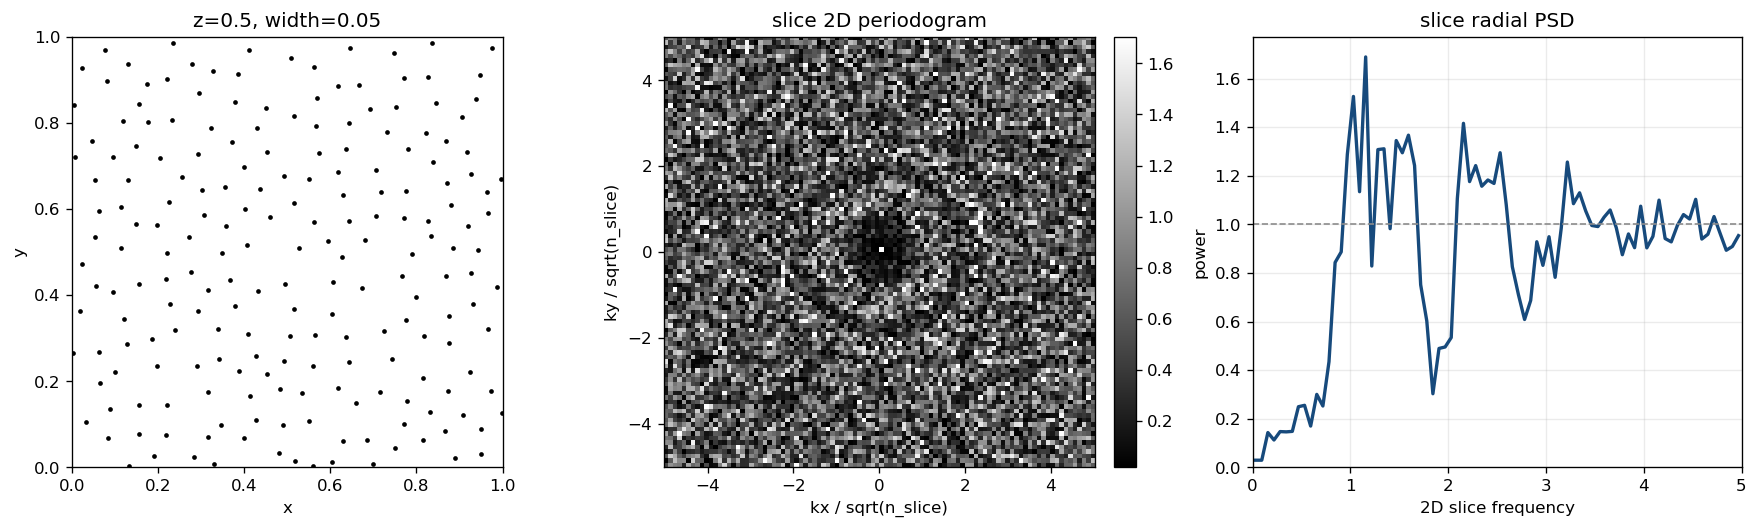

In [ ]:
# Single 3D slice diagnostic with 2D periodogram and radial PSD
slice_z = 0.5
slice_width = 0.05
slice_psd_grid_size = 96
slice_num_bins = 80
slice_max_freq = 5.0

slice_dz = np.abs(points_3d[:, 2] - slice_z)
slice_dz = np.minimum(slice_dz, 1.0 - slice_dz)
slice_points = points_3d[slice_dz < 0.5 * slice_width][:, :2]
print(f"slice points: {slice_points.shape[0]} / {points_3d.shape[0]}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=120)
axes[0].scatter(slice_points[:, 0], slice_points[:, 1], s=8, c="black", linewidths=0)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].set_aspect("equal")
axes[0].set_title(f"z={slice_z}, width={slice_width}")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

if slice_points.shape[0] >= 2:
	power_2d, extent = ds_wave.compute_periodogram_2d(
		slice_points,
		grid_size=slice_psd_grid_size,
		max_freq=slice_max_freq,
	)
	display_power = power_2d.copy()
	display_power[display_power.shape[0] // 2, display_power.shape[1] // 2] = np.nan
	log_power = np.log1p(display_power)
	vmin, vmax = np.nanpercentile(log_power, [2.0, 99.0])
	image = axes[1].imshow(
		log_power,
		origin="lower",
		extent=extent,
		cmap="gray",
		vmin=vmin,
		vmax=vmax,
		interpolation="nearest",
	)
	axes[1].set_title("slice 2D periodogram")
	axes[1].set_xlabel("kx / sqrt(n_slice)")
	axes[1].set_ylabel("ky / sqrt(n_slice)")
	fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)

	freqs, radial = ds_wave.compute_radial_psd(
		slice_points,
		num_bins=slice_num_bins,
		max_freq=slice_max_freq,
		mode_limit=8192,
	)
	axes[2].plot(freqs, radial, color="#174a7c", linewidth=2.0)
	axes[2].axhline(1.0, color="0.55", linestyle="--", linewidth=1)
	axes[2].set_xlim(0.0, slice_max_freq)
	axes[2].set_ylim(bottom=0.0)
	axes[2].set_title("slice radial PSD")
	axes[2].set_xlabel("2D slice frequency")
	axes[2].set_ylabel("power")
	axes[2].grid(True, alpha=0.25)
else:
	axes[1].set_axis_off()
	axes[2].set_axis_off()

fig.tight_layout()
fig.show()
